In [1]:
# import sys, os
# if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
#     !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash

#     !pip -q install gymnasium[mujoco,toy_text]
#     !pip -q install mujoco==2.3.7

#     %env MUJOCO_GL=egl

#     !touch .setup_complete

# # This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
# if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
#     !bash ../xvfb start
#     os.environ['DISPLAY'] = ':1'

In [3]:
import gymnasium as gym
import numpy as np
import time
import matplotlib.pyplot as plt

from gymnasium.wrappers import RecordVideo
from IPython.display import clear_output, display

# 1. Cross-Entropy Method

This notebook will teach you to solve reinforcement learning problems with crossentropy method.

Initialise points distribution $q_0$.
Repeat until convergence, $k = 0, 1, \dots$:
1. Sample from $\{x_i \}_{i=1}^N ∼ q_k$
2. Select $M \leq N$ elite points based on criteria
4. Update to get new distribution $q_{k+1}$

Distribution update: $\large D_{KL}(p_{\text{elites}} || q) = \mathbb{E}_{p_{\text{elites}}} [ \log(\dfrac{p_{\text{elites}}(x)}{q(x)})] = -\mathbb{E}_{p_{\text{elites}}}[\log(q(x))] + const \to \min\limits_q$

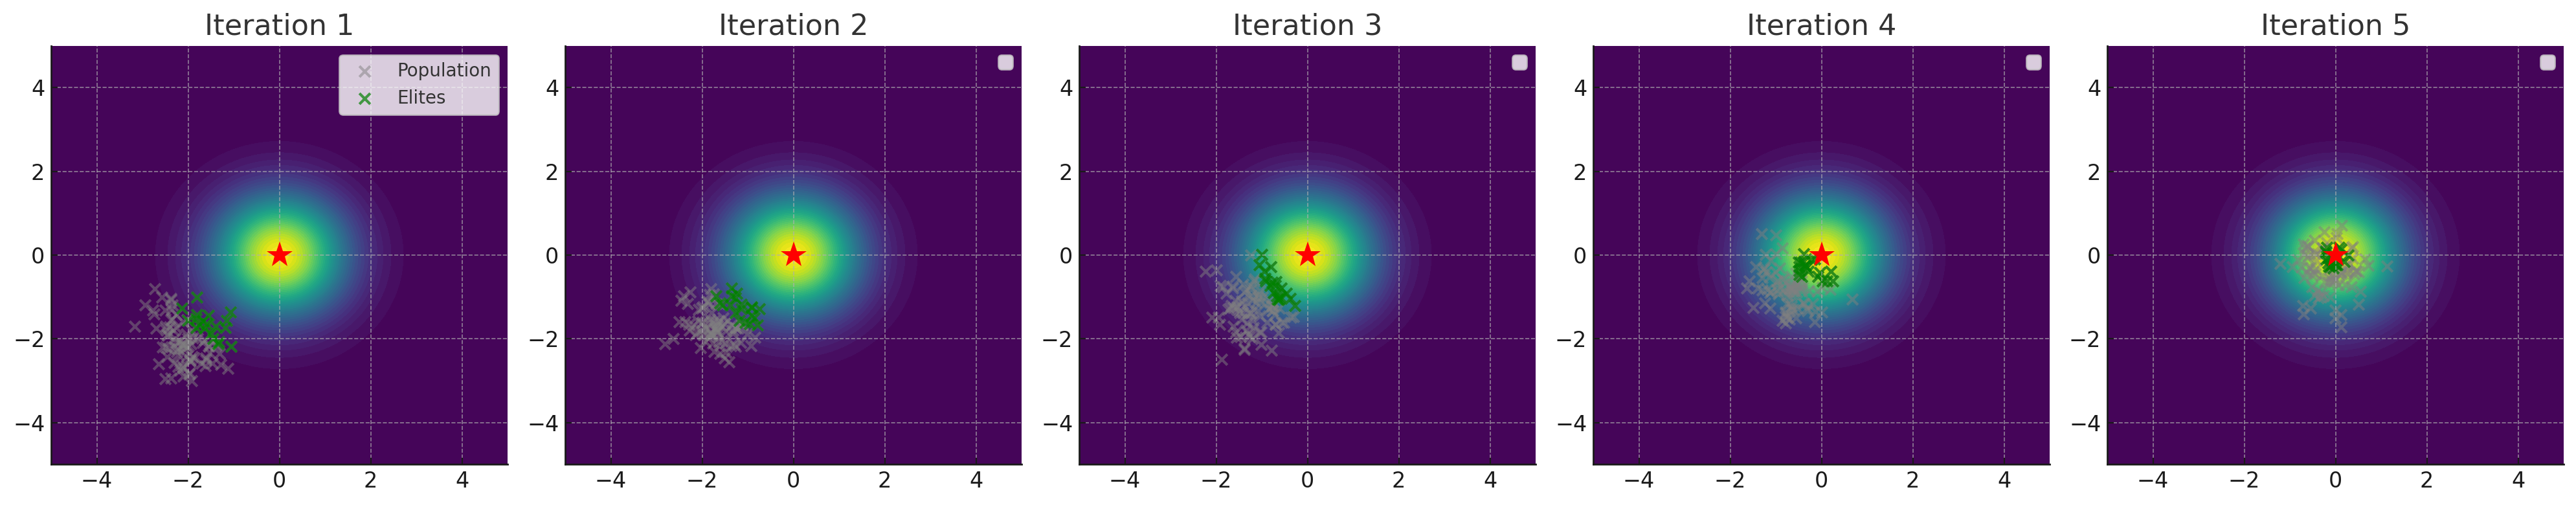

1. **Изначально:**  
   У нас стоит задача **минимизировать** KL-дивергенцию между $p_{\text{elites}}$ и $q$:
   $
   D_{KL}(p_{\text{elites}} \| q) \to \min_q
   $

2. **Мы заметили:**  
   Это то же самое, что **максимизировать** следующую штуку:
   $
   \mathbb{E}_{p_{\text{elites}}}[\log(q(x))] \to \max_q
   $
   (поменяли знак минуса на плюс, и теперь задача стала задачей максимизации).

3. **Интуитивно:**  
   Мы хотим подобрать такую модель $q(x)$, чтобы она **максимально хорошо объясняла** выборку, полученную из $p_{\text{elites}}$.

4. **q(x) — это параметризованная модель:**  
   Например, $q(x;\theta)$, где $\theta$ — параметры модели (весовые коэффициенты, мат. ожидание и ковариация в случае гауссианы и т.п.).
   
   Мы не можем оптимизировать по всем возможным функциям (это бесконечное пространство), поэтому выбираем определённый класс моделей (семейство распределений), который мы **можем описывать параметрами**.

5. **Что происходит фактически:**  
   - Мы ищем такие параметры $\theta$, чтобы вероятность $q(x; \theta)$ была **как можно больше** для тех $x$, которые пришли из $p_{\text{elites}}$.
   - То есть мы **максимизируем правдоподобие** (log-likelihood) элитных точек относительно модели $q$.

6. **В итоге:**  
   Мы свели задачу к классической задаче **обучения модели на данных** — почти как в регрессии или классификации:
   - **В регрессии/классификации**: мы подгоняем модель под размеченные данные.
   - **Здесь**: мы подгоняем вероятностную модель $q$ под данные (набор элитных точек).

**Итоговая мысль:**
> Оптимизация KL-дивергенции свелась к обучению параметрической модели максимизацией правдоподобия на выборке из лучших решений.

И это идея стоит за методами типа:
- **Cross-Entropy Method (CEM)**
- **CMA-ES**
- **Policy Gradient в RL**
- **EM-алгоритм** (Expectation-Maximization)

Если $ q(x) $ — **гауссовское распределение**, то его параметры:
- $ \mu $ — вектор среднего,
- $ \Sigma $ — матрица ковариации.

Тогда задача:
$
(\mu, \Sigma) = \arg\max_{\mu, \Sigma} \, \mathbb{E}_{x \sim p_{\text{elites}}}[\log \mathcal{N}(x \mid \mu, \Sigma)]
$

То есть мы подгоняем $ \mu $ и $ \Sigma $ так, чтобы $q$ максимально хорошо аппроксимировал распределение элитных точек.

# Taxi-v3

### `Rewards`
* -1 per step unless other reward is triggered.
* +20 delivering passenger.
* -10 executing “pickup” and “drop-off” actions illegally.



(413, {'prob': 1.0, 'action_mask': array([0, 1, 0, 0, 0, 0], dtype=int8)})


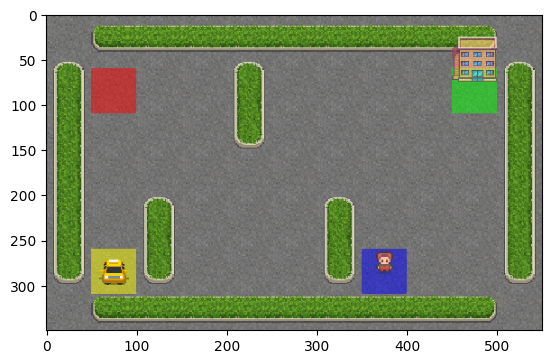

In [3]:
env = gym.make("Taxi-v3", render_mode="rgb_array")
print(env.reset(seed=1345))
plt.imshow(env.render())

In [4]:
n_states = env.observation_space.n
n_actions = env.action_space.n

print(f"observation_space: {env.observation_space}")
print(f"action_space: {env.action_space}")

observation_space: Discrete(500)
action_space: Discrete(6)


### Create stochastic policy

This time our policy should be a probability distribution.

```policy[s,a] = P(take action a | in state s)```

Since we still use integer state and action representations, you can use a 2-dimensional array to represent the policy.

Please initialize the policy __uniformly__, that is, probabililities of all actions should be equal.

In [5]:
def initialize_policy(n_states, n_actions):
    # <YOUR CODE: create an array to store action probabilities>
    return np.ones((n_states, n_actions)) / n_actions

policy = initialize_policy(n_states, n_actions)

### Play the game

Just like before, but we also record all states and actions we took.

In [6]:
def generate_session(env, policy, t_max=250):
    """
    Play game until end or for t_max ticks.
    :param policy: an array of shape [n_states,n_actions] with action probabilities
    :returns: list of states, list of actions and sum of rewards
    """
    states, actions = [], []
    total_reward = 0.

    s, _ = env.reset()

    for t in range(t_max):
        # Hint: you can use np.random.choice for sampling action
        # https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html

        a = np.random.choice(n_actions, p=policy[s], size=1)[0] #<YOUR CODE: sample action from polic

        new_s, r, terminated, truncated, _ = env.step(a)

        # Record information we just got from the environment.
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward

In [7]:
s, a, r = generate_session(env, policy)
assert isinstance(s, list)
assert isinstance(a, list)
assert len(s) == len(a)
assert isinstance(r, float)

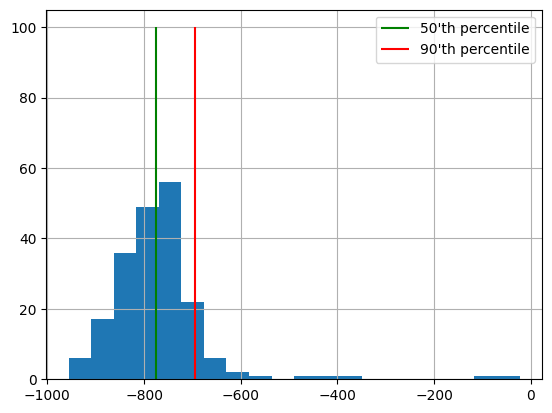

In [8]:
sample_rewards = [generate_session(env, policy, t_max=1000)[-1] for _ in range(200)]

plt.hist(sample_rewards, bins=20)
plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label="50'th percentile", color='green')
plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label="90'th percentile", color='red')
plt.legend()
plt.grid()

In [9]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile) #<YOUR CODE: compute minimum reward for elite sessions. Hint: use np.percentile()>
    elite_states, elite_actions = [], []
    for i in range(len(rewards_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions

In [10]:
states_batch = [
    [1, 2, 3],     # game1
    [4, 2, 0, 2],  # game2
    [3, 1],        # game3
]

actions_batch = [
    [0, 2, 4],     # game1
    [3, 2, 0, 1],  # game2
    [3, 3],        # game3
]
rewards_batch = [
    3,  # game1
    4,  # game2
    5,  # game3
]

test_result_0 = select_elites(states_batch, actions_batch, rewards_batch, percentile=0)
test_result_30 = select_elites(states_batch, actions_batch, rewards_batch, percentile=30)
test_result_90 = select_elites(states_batch, actions_batch, rewards_batch, percentile=90)
test_result_100 = select_elites(states_batch, actions_batch, rewards_batch, percentile=100)

assert np.all(test_result_0[0] == [1, 2, 3, 4, 2, 0, 2, 3, 1])  \
    and np.all(test_result_0[1] == [0, 2, 4, 3, 2, 0, 1, 3, 3]), \
    "For percentile 0 you should return all states and actions in chronological order"
assert np.all(test_result_30[0] == [4, 2, 0, 2, 3, 1]) and \
    np.all(test_result_30[1] == [3, 2, 0, 1, 3, 3]), \
    "For percentile 30 you should only select states/actions from two first"
assert np.all(test_result_90[0] == [3, 1]) and \
    np.all(test_result_90[1] == [3, 3]), \
    "For percentile 90 you should only select states/actions from one game"
assert np.all(test_result_100[0] == [3, 1]) and\
    np.all(test_result_100[1] == [3, 3]), \
    "Please make sure you use >=, not >. Also double-check how you compute percentile."

print("Ok!")

Ok!


In [11]:
def get_new_policy(elite_states, elite_actions):
    """
    Given a list of elite states/actions from select_elites,
    return a new policy where each action probability is proportional to

        policy[s_i,a_i] ~ #[occurrences of s_i and a_i in elite states/actions]

    Don't forget to normalize the policy to get valid probabilities and handle the 0/0 case.
    For states that you never visited, use a uniform distribution (1/n_actions for all states).

    :param elite_states: 1D list of states from elite sessions
    :param elite_actions: 1D list of actions from elite sessions

    """

    new_policy = np.zeros([n_states, n_actions])

    # <YOUR CODE: set probabilities for actions given elite states & actions>
    # Don't forget to set 1/n_actions for all actions in unvisited states.
    for state, action in zip(elite_states, elite_actions):
        new_policy[state, action] += 1

    new_policy[new_policy.sum(axis=1) == 0] = 1
    new_policy /= new_policy.sum(axis=1, keepdims=True)
    
    return new_policy

In [12]:
elite_states = [1, 2, 3, 4, 2, 0, 2, 3, 1]
elite_actions = [0, 2, 4, 3, 2, 0, 1, 3, 3]

new_policy = get_new_policy(elite_states, elite_actions)

assert np.isfinite(new_policy).all(), \
    "Your new policy contains NaNs or +-inf. Make sure you don't divide by zero."
assert np.all(new_policy >= 0), \
    "Your new policy can't have negative action probabilities"
assert np.allclose(new_policy.sum(axis=-1), 1), \
    "Your new policy should be a valid probability distribution over actions"

reference_answer = np.array([
    [1.,  0.,  0.,  0.,  0.],
    [0.5,  0.,  0.,  0.5,  0.],
    [0.,  0.33333333,  0.66666667,  0.,  0.],
    [0.,  0.,  0.,  0.5,  0.5]])
assert np.allclose(new_policy[:4, :5], reference_answer)

print("Ok!")

Ok!


### Training loop
Generate sessions, select N best and fit to those.

In [13]:
# def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
#     """
#     A convenience function that displays training progress.
#     No cool math here, just charts.
#     """
#     mean_reward = np.mean(rewards_batch)
#     threshold = np.percentile(rewards_batch, percentile)
#     log.append([mean_reward, threshold])

#     plt.figure(figsize=[8, 4])
#     plt.subplot(1, 2, 1)
#     plt.plot(list(zip(*log))[0], label='Mean rewards')
#     plt.plot(list(zip(*log))[1], label='Reward thresholds')
#     plt.legend()
#     plt.grid()

#     plt.subplot(1, 2, 2)
#     plt.hist(rewards_batch, range=reward_range)
#     plt.vlines([np.percentile(rewards_batch, percentile)],
#                [0], [100], label="percentile", color='red')
#     plt.legend()
#     plt.grid()
#     # clear_output(True)
#     print(f"mean reward = {mean_reward:.3f}, threshold={threshold:.3f}")
#     plt.show()

In [14]:
def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    mean_rewards, thresholds = zip(*log)

    ax1.clear()
    ax1.plot(mean_rewards, label='Mean rewards')
    ax1.plot(thresholds, label='Reward thresholds')
    ax1.legend()
    ax1.grid()
    ax1.set_title("Rewards over time")

    ax2.clear()
    ax2.hist(rewards_batch, range=reward_range)
    ax2.vlines([threshold], 0, 100, label="percentile", color='red')
    ax2.legend()
    ax2.grid()
    ax2.set_title("Rewards distribution")

    clear_output(wait=True)
    display(fig)
    print(f"mean reward = {mean_reward:.3f}, threshold={threshold:.3f}")

In [15]:
# reset policy just in case
policy = initialize_policy(n_states, n_actions)

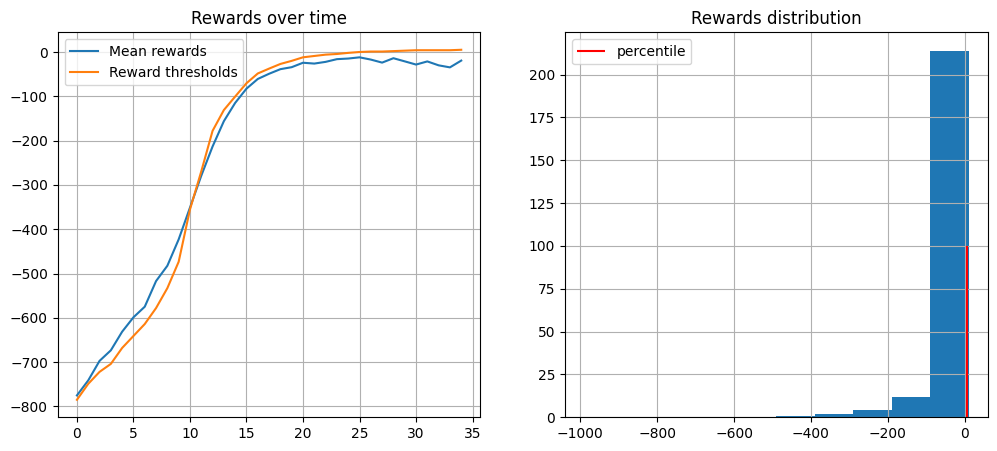

mean reward = -19.408, threshold=5.000


In [16]:
n_sessions = 250     # sample this many sessions
percentile = 50      # discard this percentage of sessions with lowest rewards
learning_rate = 0.5  # how quickly the policy is updated, on a scale from 0 to 1

log = []

# Создадим фигуру и оси один раз
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
mean_rewards, thresholds = [], []

for i in range(35):
    %time sessions = [generate_session(env, policy) for _ in range(n_sessions)]# <YOUR CODE: generate a list of n_sessions new sessions>

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile=percentile) #<YOUR CODE: select elite states & actions>

    new_policy = get_new_policy(elite_states, elite_actions) #<YOUR CODE: compute new policy>

    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    # display results on chart
    show_progress(rewards_batch, log, percentile)
    
plt.close(fig)

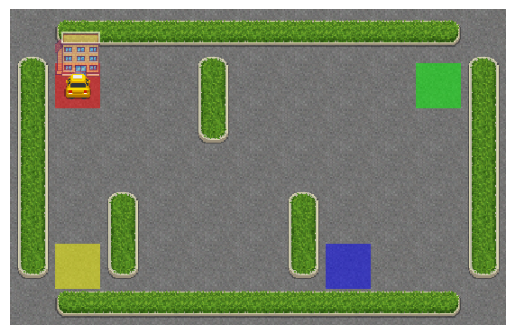

In [17]:
env = gym.make("Taxi-v3", render_mode="rgb_array")
state, info = env.reset()

# интерактив для matplotlib-inline
# plt.ioff()                   # отключаем автоматический вывод фигуры
fig, ax = plt.subplots()
img = ax.imshow(env.render())   # первый кадр
ax.axis('off')

done = False
while not done:
    # action = np.random.randint(env.action_space.n) 
    action = np.argmax(policy[state])
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    img.set_data(env.render())  # меняем «картинку» внутри той же figure

    clear_output(wait=True)     # стираем прошлый вывод
    display(fig)                # и выводим обновлённый
    time.sleep(0.5)            # пауза, чтобы глаз успел заметить

plt.close(fig)

In [21]:
import imageio

env = gym.make("Taxi-v3", render_mode="rgb_array")
state, info = env.reset()

frames = []  # список для кадров

done = False
while not done:
    frame = env.render()
    frames.append(frame)  # сохраняем текущий кадр

    action = np.argmax(policy[state])  # ваш policy
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

imageio.mimsave("taxi_gif/taxi_animation_1.gif", frames, fps=2)

### Reflecting on results

You may have noticed that the taxi problem quickly converges from less than -1000 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

In case CEM failed to learn how to win from one distinct starting point, it will simply discard it because no sessions from that starting point will make it into the "elites".

To mitigate that problem, you can either reduce the threshold for elite sessions (duct tape way) or change the way you evaluate strategy (theoretically correct way). For each starting state, you can sample an action randomly, and then evaluate this action by running _several_ games starting from it and averaging the total reward. Choosing elite sessions with this kind of sampling (where each session's reward is counted as the average of the rewards of all sessions with the same starting state and action) should improve the performance of your policy.

Этот метод дороже по времени и сходится медленее. Поэтому он подходит для доообучения. Или аналогичного результата можно добиться меняя шаг динамически в первом алгоритме.

In [99]:
def evaluate_state_action(env, state, action, policy, n_attempts=5, t_max=100):
    total_rewards = []
    for _ in range(n_attempts):
        env.reset()
        env.env.s = state  # напрямую задаем состояние среды
        new_state, reward, terminated, truncated, _ = env.step(action)
        total_reward = reward
        s = new_state
        
        for _ in range(t_max):
            if terminated or truncated:
                break
            next_action = np.random.choice(n_actions, p=policy[s])
            s, reward, terminated, truncated, _ = env.step(next_action)
            total_reward += reward

        total_rewards.append(total_reward)

    return np.mean(total_rewards)
    

def select_elites_with_avg(env, states_batch, actions_batch, policy, percentile, n_attempts=5):
    start_state_action_pairs = [(states[0], actions[0]) for states, actions in zip(states_batch, actions_batch)]
    unique_pairs = list(set(start_state_action_pairs))

    rewards_for_pairs = {}
    for state, action in unique_pairs:
        rewards_for_pairs[(state, action)] = evaluate_state_action(env, state, action, policy, n_attempts)

    session_avg_rewards = [rewards_for_pairs[(states[0], actions[0])] for states, actions in zip(states_batch, actions_batch)]

    reward_threshold = np.percentile(session_avg_rewards, percentile)

    elite_states, elite_actions = [], []
    for i in range(len(session_avg_rewards)):
        if session_avg_rewards[i] >= reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions

In [88]:
log = []
# Создадим фигуру и оси один раз

mean_rewards, thresholds = [], []

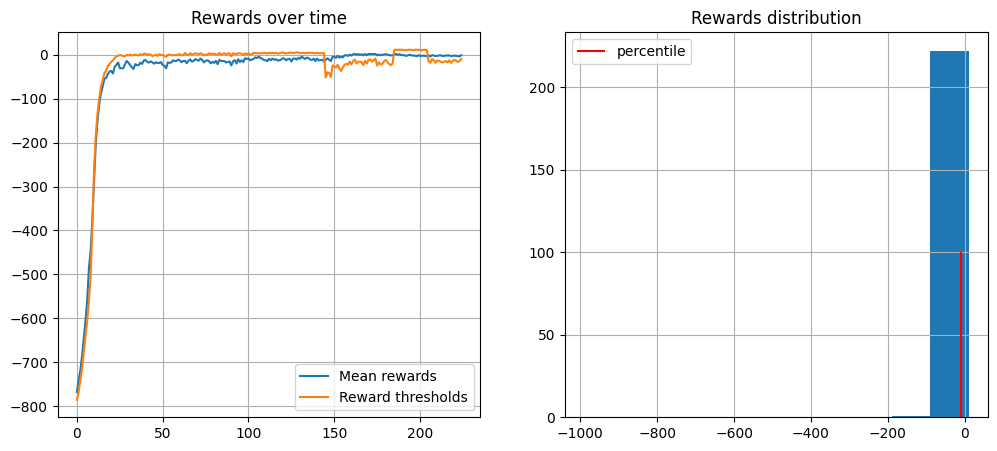

mean reward = -1.236, threshold=-9.650


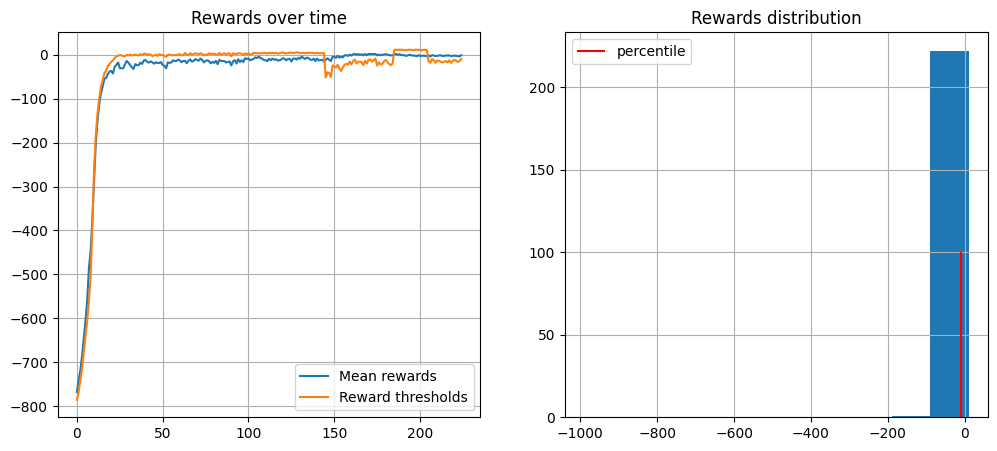

In [105]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

n_sessions = 250     # sample this many sessions
percentile = 15      # discard this percentage of sessions with lowest rewards
learning_rate = 0.01  # how quickly the policy is updated, on a scale from 0 to 1

for i in range(20):
    sessions = [generate_session(env, policy) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites_with_avg(env, states_batch, actions_batch, policy, percentile, n_attempts=10)

    new_policy = get_new_policy(elite_states, elite_actions)

    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    show_progress(rewards_batch, log, percentile)

plt.close(fig)

# 2. Deep Cross-Entropy Method

Now assume that $\pi_\theta(s)$ is a neural network instead of just a table.
So we optimise either Cross-Entropy Loss or MSE (or Gaussian Likelihood) depending on acton space.

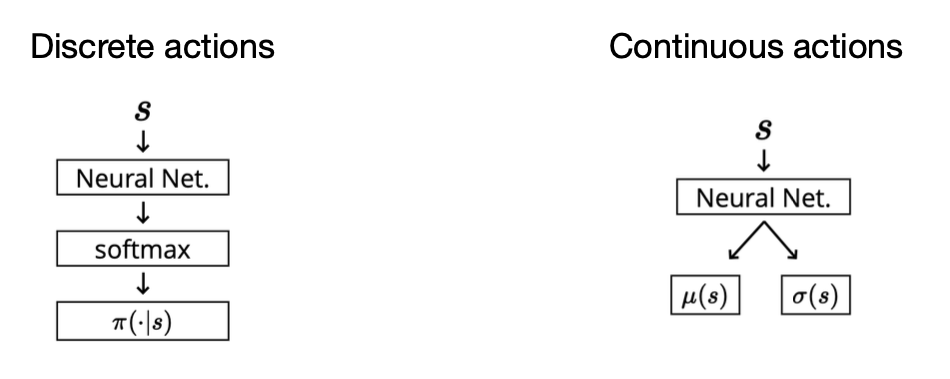

## Continuous actions:

- Нейросеть даёт $ \mu(s) $ и $ \sigma(s) $.
- Мы рассматриваем действия как выборку из нормального распределения $ \mathcal{N}(\mu(s), \sigma(s)) $.
- Лосс — это минус логарифм плотности вероятности Гауссианы для действия, которое было сделано:
  
**Формально:**
$
\text{Loss} = -\log \mathcal{N}(a^* \mid \mu(s), \sigma(s))
$
или
$
\text{Loss} = \frac{(a^* - \mu(s))^2}{2\sigma^2} + \log \sigma
$

- В упрощенном случае можно фиксировать $ \sigma $ и оптимизировать только $ \mu $ (будет MSE).

## Discrete actions

- Нейросеть даёт Softmax-распределение $ \pi(a|s) $.
- Можно использовать **Cross-Entropy Loss** между предсказанной вероятностью и "идеальными" действиями (например, из элитных сессий).
- Или напрямую обновлять веса, увеличивая вероятность тех действий, которые вели к высоким наградам.

**Формально:** если $ a^* $ — действие из элитной сессии,
$
\text{Loss} = -\log \pi_\theta(a^* | s)
$

In [226]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Среда
env = gym.make('Taxi-v3')
n_states = env.observation_space.n  # 500 состояний
n_actions = env.action_space.n      # 6 действий

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Сетка
class PolicyNet(nn.Module):
    def __init__(self, n_states, n_actions):
        super(PolicyNet, self).__init__()
        self.model = nn.Sequential(
            nn.Embedding(n_states, 128),  # Специально для дискретных состояний
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions)
        )
    
    def forward(self, state):
        logits = self.model(state)
        return logits 

policy_net = PolicyNet(n_states, n_actions).to(device)
optimizer = optim.Adam(policy_net.parameters(), lr=1e-2)
criterion = nn.CrossEntropyLoss()


def generate_session(env, policy_net, t_max=1000):
    states, actions, total_reward = [], [], 0
    s, _ = env.reset()
    
    for t in range(t_max):
        state_v = torch.tensor([s], dtype=torch.long, device=device)
        logits = policy_net(state_v)
        probs = torch.softmax(logits, dim=1).cpu().detach().numpy()[0]
        a = np.random.choice(n_actions, p=probs)
        
        new_s, r, terminated, truncated, _ = env.step(a)

        states.append(s)
        actions.append(a)
        total_reward += r
        
        s = new_s
        if terminated or truncated:
            break
    
    return states, actions, total_reward


def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    reward_threshold = np.percentile(rewards_batch, percentile)
    elite_states, elite_actions = [], []
    
    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
        if reward >= reward_threshold:
            elite_states.extend(states)
            elite_actions.extend(actions)
    
    return elite_states, elite_actions

In [214]:
# Трайн луп
n_sessions = 100
percentile = 50
n_epochs = 25

for epoch in range(n_epochs):
    sessions = [generate_session(env, policy_net) for _ in range(n_sessions)]
    
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    if not elite_states:
        print(f"Epoch {epoch}: No elite sessions found. Skipping...")
        continue

    elite_states_v = torch.tensor(elite_states, dtype=torch.long, device=device)
    elite_actions_v = torch.tensor(elite_actions, dtype=torch.long, device=device)
    
    optimizer.zero_grad()
    logits = policy_net(elite_states_v)
    loss = criterion(logits, elite_actions_v)
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch}: loss = {loss.item():.3f}, mean reward = {np.mean(rewards_batch):.3f}")

Epoch 0: loss = 1.765, mean reward = -698.070
Epoch 1: loss = 1.742, mean reward = -617.770
Epoch 2: loss = 1.711, mean reward = -560.150
Epoch 3: loss = 1.688, mean reward = -509.880
Epoch 4: loss = 1.668, mean reward = -483.100
Epoch 5: loss = 1.642, mean reward = -450.750
Epoch 6: loss = 1.630, mean reward = -452.880
Epoch 7: loss = 1.624, mean reward = -441.210
Epoch 8: loss = 1.630, mean reward = -439.980
Epoch 9: loss = 1.620, mean reward = -437.310
Epoch 10: loss = 1.631, mean reward = -453.050
Epoch 11: loss = 1.641, mean reward = -448.830
Epoch 12: loss = 1.649, mean reward = -472.440
Epoch 13: loss = 1.664, mean reward = -476.540
Epoch 14: loss = 1.665, mean reward = -488.870
Epoch 15: loss = 1.669, mean reward = -501.320
Epoch 16: loss = 1.685, mean reward = -516.780


KeyboardInterrupt: 

In [218]:
env = gym.make("Taxi-v3", render_mode="rgb_array")
state, info = env.reset()

fig, ax = plt.subplots()
img = ax.imshow(env.render())   # первый кадр
ax.axis('off')

policy_net.eval()  # отключаем режим обучения
done = False
while not done:
    state_v = torch.tensor([state], dtype=torch.long, device=device)
    with torch.no_grad():
        logits = policy_net(state_v)
        action = torch.argmax(logits, dim=1).item()

    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    img.set_data(env.render())  # обновляем изображение

    clear_output(wait=True)
    display(fig)
    time.sleep(0.5)

plt.close(fig)

### nn.CrossEntropyLoss()

Если агент ничего не научился делать и просто рандомно двигается, он всегда получает ~-200 при 

`generate_session(env, policy_net, t_max=200)`

```
# nn.CrossEntropyLoss()
Epoch 0: loss = 1.772, mean reward = -775.740
Epoch 1: loss = 1.749, mean reward = -674.700
Epoch 2: loss = 1.710, mean reward = -579.580
Epoch 3: loss = 1.643, mean reward = -480.780
Epoch 4: loss = 1.577, mean reward = -407.180
Epoch 5: loss = 1.478, mean reward = -333.470
Epoch 6: loss = 1.419, mean reward = -296.890
Epoch 7: loss = 1.332, mean reward = -270.170
Epoch 8: loss = 1.267, mean reward = -242.610
Epoch 9: loss = 1.203, mean reward = -228.670
Epoch 10: loss = 1.117, mean reward = -217.890
Epoch 11: loss = 1.137, mean reward = -211.440
Epoch 12: loss = 1.106, mean reward = -208.370
Epoch 13: loss = 1.079, mean reward = -208.370
Epoch 14: loss = 1.022, mean reward = -204.770
Epoch 15: loss = 1.010, mean reward = -202.970
Epoch 16: loss = 0.998, mean reward = -202.070
Epoch 17: loss = 0.965, mean reward = -201.710
Epoch 18: loss = 0.965, mean reward = -201.170
Epoch 19: loss = 0.946, mean reward = -200.630
```

Из вывода видно, что среднее вознаграждение улучшается с -773 до -200 на ранних эпохах, но затем стабилизируется около -200, хотя функция потерь продолжает уменьшаться. Это указывает на то, что сеть обучается воспроизводить действия из выбранных сессий, но эти действия не приводят к дальнейшему улучшению политики.

### Ограниченное разнообразие элитных сессий

Если в начале агент научился какому-то простому паттерну (например, просто кататься кругами без посадки пассажиров), то он это паттерн будет "замораживать", поскольку отбор элитных сессий усиливает уже имеющееся поведение.

Лосс уменьшается, так как сеть становится экспертом в предсказании этих конкретных действий, но они не являются оптимальными, и вознаграждение не растет.

### Метод не различает величину вознаграждения

Втекущем подходе все элитные сессии считаются равноценными, если они попали в верхние 50%. Сессия с -200 и гипотетическая сессия с +20 (если такая появится) имеют одинаковый вес в обучении.

### Попытки улучшения

* Усложнение архитектуыр не помогает.
* Выбор фиксированного количество лучших сессий (например, топ-10 или топ-20) не помогает.

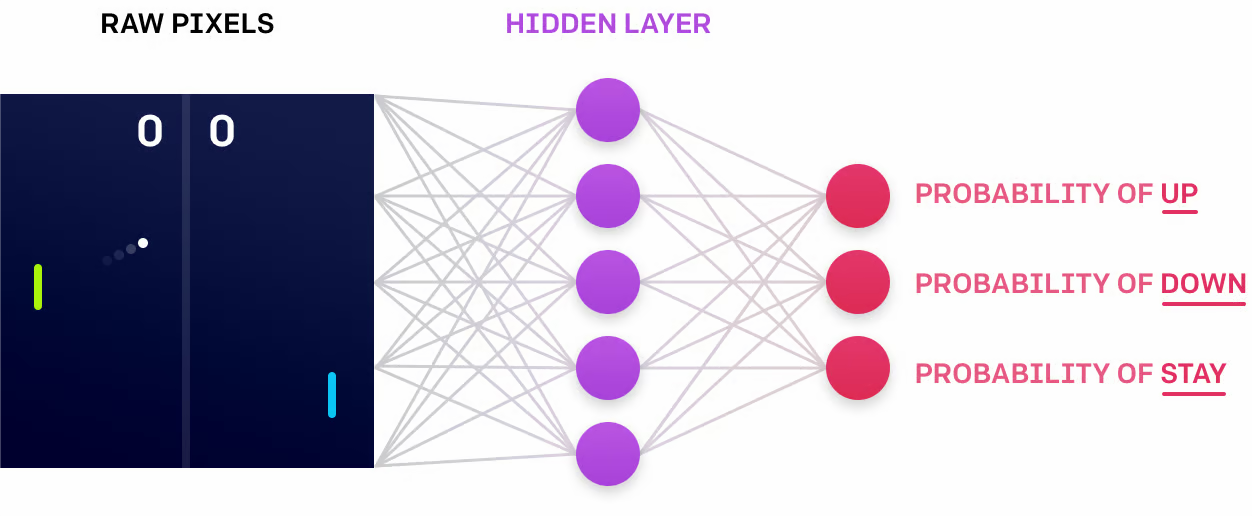

 Тут нас ждёт аналогичная история. Надо решить прошлую проблему, прежде всего

# 3. [Evolution Strategies as a Scalable Alternative to RL](https://openai.com/research/evolution-strategies)

**Evolution Strategies for RL**

$F(\theta)$ is the stochastic return provided by an
environment, and $\theta$ are the parameters of a deterministic or stochastic policy $\pi_\theta$ describing an
agent acting in that environment, controlled by either discrete or continuous actions. Since the actions are allowed to be discrete and the policy is allowed to be deterministic, $F(\theta)$ can be non-smooth in $\theta$.

1. **Objective:**
Assuming $\psi \sim p_\theta = \mathcal{N}(\theta, \sigma^2 I)$:
$$\mathbb{E}_{\psi \sim p_\theta} [F(\psi)] = \mathbb{E}_{\delta \sim \mathcal{N}(0, I)} [F(\theta + \sigma \delta)]$$

2. **Gradient:**
$$\nabla_\theta \mathbb{E}_{\delta \sim \mathcal{N}(0, I)} [F(\theta + \sigma \delta)] = \dfrac{1}{\sigma} \mathbb{E}_{\delta \sim \mathcal{N}(0, I)} [F(\theta + \sigma \delta) \delta]$$


2. **Policy Representation**:
The policy $\pi$ can be either MLP or CNN depending on the state.

3. **Sampling and Perturbations**:
  * Generate $N$ perturbations $\delta_i \sim \mathcal{N}(0, I)$
  * Compute returns $F_i = F(\theta_{old} + \sigma \delta_i)$

4. **Parameter Update Rule**:
Update the parameters using a weighted sum of perturbations:
\begin{equation}
    \theta_{new} \leftarrow \theta_{old} + \frac{\alpha}{N \sigma} \sum_{i=1}^{N} F_i \delta_{i}
\end{equation}
where $\alpha$ is the learning rate.

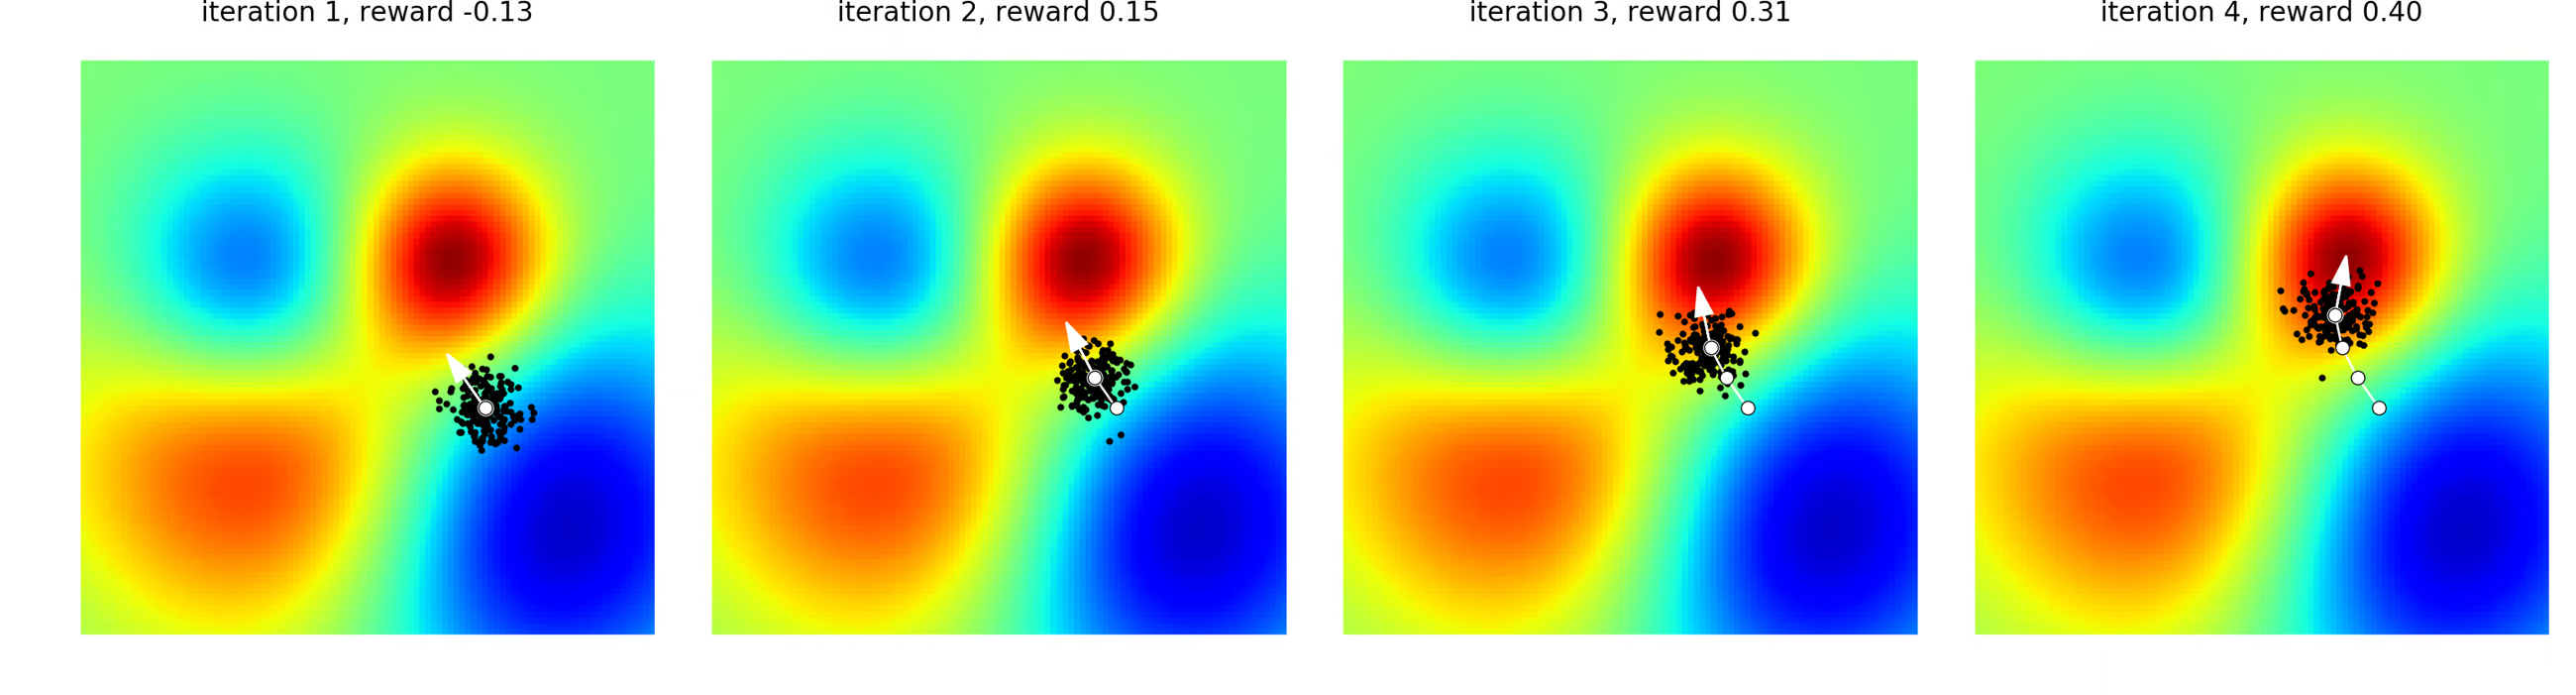

## 4. [Augmented Random Search](https://arxiv.org/abs/1803.07055)

**Augmented Random Search** is a model-free, policy-based reinforcement learning algorithm. It does not require a gradient-based approach, which is a significant departure from popular methods or policy gradient methods. Instead, ARS optimizes policy parameters directly through random search.

1. **Objective Function**:
The objective is to maximize the expected return $J(\theta)$, the cumulative reward:
\begin{equation}
    J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \sum_{t=0}^{T} R_t \right] → \max_{\theta}
\end{equation}
where $R_t$ is the reward at time $t$ and $T$ is the episode length.

2. **Policy Representation**:
The policy $\pi$ maps states $s$ to actions $a$, typically linear in this context:
\begin{equation}
    \pi_\theta(s) = \theta^T s
\end{equation}
where $\theta \in \mathbb{R}^{|S| \times |A|}$ is parameter matrix.

3. **Sampling and Perturbations**:
Generate $N$ perturbations $\delta_i$ from a normal distribution with a standard error $\sigma$:
\begin{equation}
    \theta_{old} \pm \delta_i, \quad i = 1, 2, \dots, N
\end{equation}

4. **Policy Evaluation**:

  **4.1. State Normalization (ARS-V2)**
Normalize states $s$ using running statistics (mean and standard deviation)

  **4.2. Compute returns for perturbed policies**
\begin{align}
    J(\theta_{old} + \delta_i) \quad &\text{and} \quad J(\theta_{old} - \delta_i)
\end{align}

5. **Parameter Update Rule**:
Update the parameters using a weighted sum of perturbations:
\begin{equation}
    \theta_{new} \leftarrow \theta_{old} + \frac{\alpha}{b \sigma_R} \sum_{i=1}^{b} \left( J(\theta_{old} + \delta_{i}) - J(\theta_{old} - \delta_{i}) \right) \delta_{i}
\end{equation}
where $\alpha$ is the learning rate, $b \leq N$ is the number of top-performing perturbations, and $\sigma_R$ is the standard deviation of the $2b$ returns.


In [78]:
class LinearPolicy:
    def __init__(self, state_dim=None, action_dim=None, weights=None):
        self.weights = np.zeros((state_dim, action_dim)) if weights is None else weights

    def get_action(self, state):
        return self.weights.T @ state

    def update_weights(self, weights):
        self.weights = weights

In [79]:
def evaluate_policy(env, policy, rollout_length):
    state, _ = env.reset()
    episode_reward = 0
    for i in range(rollout_length):
        action = policy.get_action(state)
        next_s, reward, terminated, truncated, _ = env.step(action)
        episode_reward += reward
        state = next_s
        if terminated or truncated:
            break

    return episode_reward

In [Mujoco](https://gymnasium.farama.org/environments/mujoco/) tasks, which often involve complex physical simulations and continuous action spaces, ARS has been shown to perform well. Its ability to handle continuous, high-dimensional action spaces without the need for complex neural network architectures or gradient calculations makes it particularly suited for such environments.

action_space: Box(-1.0, 1.0, (2,), float32)
state_space: Box(-inf, inf, (8,), float64)


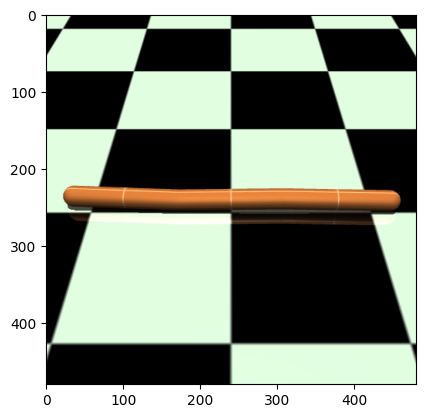

In [80]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import matplotlib.pyplot as plt

env = gym.make("Swimmer-v5", render_mode="rgb_array")
print(f"action_space: {env.action_space}")
print(f"state_space: {env.observation_space}")
env.reset()
plt.imshow(env.render());

In [81]:
env = gym.make("Swimmer-v5", render_mode="rgb_array")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
policy = LinearPolicy(weights=np.random.randn(state_dim, action_dim))
evaluate_policy(env, policy, 1000)

np.float64(-46.72373553814177)

In [82]:
def pertubate_and_evaluate(env, weights, delta, rollout_length):
    policy = LinearPolicy(weights=weights + delta) #<YOUR CODE: create pertubated policy>
    return evaluate_policy(env, policy, rollout_length)

In [83]:
from joblib import Parallel, delayed
from IPython.display import clear_output

def train_augmented_random_search(env,
                                  policy=None,
                                  n_iter=100,
                                  sigma=0.02,
                                  n_jobs=16,
                                  n_directions=16,
                                  top_n_directions=8,
                                  learning_rate=0.01,
                                  rollout_length=1000):

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    policy = policy or LinearPolicy(state_dim=state_dim, action_dim=action_dim)
    reward_history = []

    for i in range(n_iter):
        reward_history.append(evaluate_policy(env, policy, rollout_length))

        deltas = np.random.randn(n_directions, state_dim, action_dim) # Sampling and Perturbations
        weights = policy.weights
        positive_reward = np.array(
            Parallel(n_jobs=n_jobs)(
                delayed(pertubate_and_evaluate)(env, weights,
                                                sigma * deltas[j], rollout_length)
                for j in range(n_directions)
            )
        )
        negative_reward = np.array(
            Parallel(n_jobs=n_jobs)(
                delayed(pertubate_and_evaluate)(env, weights,
                                                -sigma * deltas[j], rollout_length)
                for j in range(n_directions)
            )
        )

        sigma_reward = np.std([*positive_reward, *negative_reward])

        gradient = np.mean(
            (positive_reward - negative_reward).reshape(n_directions, 1, 1) * deltas, axis=0
        )
        new_weights = policy.weights + learning_rate / sigma_reward * gradient
        policy.update_weights(new_weights)

        if (i + 1) % 10 == 0:
            clear_output(wait=True)
            plt.figure()
            plt.plot(reward_history)
            plt.grid()
            plt.xlabel("n_iterations")
            plt.ylabel("total_reward")
            plt.show()

    return policy

5. **Parameter Update Rule**:
Update the parameters using a weighted sum of perturbations:
\begin{equation}
    \theta_{new} \leftarrow \theta_{old} + \frac{\alpha}{b \sigma_R} \sum_{i=1}^{b} \left( J(\theta_{old} + \delta_{i}) - J(\theta_{old} - \delta_{i}) \right) \delta_{i}
\end{equation}
where $\alpha$ is the learning rate, $b \leq N$ is the number of top-performing perturbations, and $\sigma_R$ is the standard deviation of the $2b$ returns.

## Swimmer

reward = forward_reward - ctrl_cost

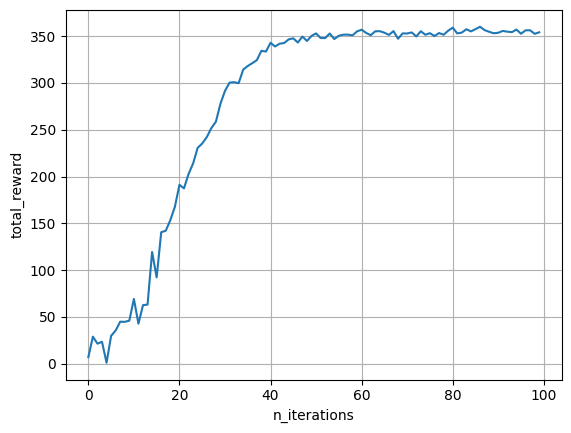

In [263]:
env = gym.make("Swimmer-v4", render_mode="rgb_array")
policy = train_augmented_random_search(env=env)

In [265]:
# !pip install "gymnasium[other]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 112.9 kB/s eta 0:00:0000:0200:07
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 168.2 kB/s eta 0:00:00a 0:00:02
  Attempting uninstall: pillow
    Found existing installation: pillow 11.1.0
    Uninstalling pillow-11.1.0:
      Successfully uninstalled pillow-11.1.0

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [266]:
with gym.make("Swimmer-v4", render_mode="rgb_array") as env, RecordVideo(
    env=env, video_folder="./videos"
) as env_monitor:
    evaluate_policy(env_monitor, policy, 1000)

In [268]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.
import sys
from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path('videos').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[0]  # You can also try other indices

if 'google.colab' in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open('rb') as fp:
        mp4 = fp.read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

## HalfCheetah

reward = forward_reward - ctrl_cost

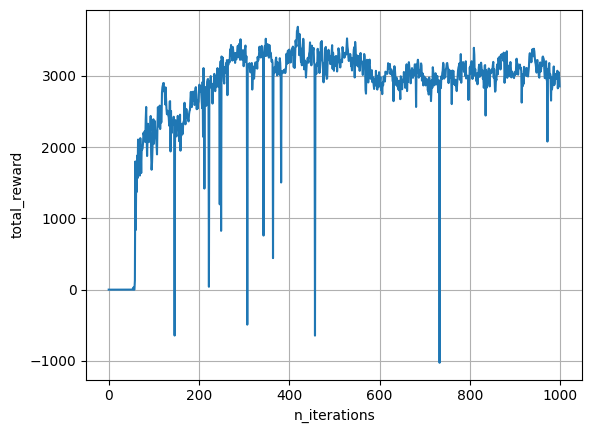

In [33]:
env = gym.make("HalfCheetah-v4", render_mode="rgb_array")
policy = train_augmented_random_search(env=env, n_iter=1000)

In [34]:
with gym.make("HalfCheetah-v4", render_mode="rgb_array") as env, RecordVideo(
    env=env, video_folder="./videos"
) as env_monitor:
    evaluate_policy(env_monitor, policy, 1000)

In [35]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.
import sys
from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path('videos').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[0]  # You can also try other indices

if 'google.colab' in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open('rb') as fp:
        mp4 = fp.read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

## Ant

reward = healthy_reward + forward_reward - ctrl_cost

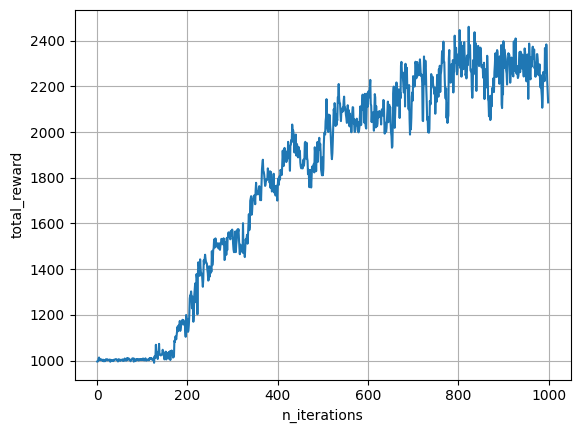

In [272]:
env = gym.make("Ant-v4", render_mode="rgb_array")
policy = train_augmented_random_search(env=env, n_iter=1000)

In [313]:
with gym.make("Ant-v4", render_mode="rgb_array") as env, RecordVideo(
    env=env, video_folder="./videos"
) as env_monitor:
    evaluate_policy(env_monitor, policy, 200)

In [314]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path('videos').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[0]  # You can also try other indices

if 'google.colab' in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open('rb') as fp:
        mp4 = fp.read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

### Humanoid-v1

action_space: Box(-0.4, 0.4, (17,), float32)
state_space: Box(-inf, inf, (348,), float64)


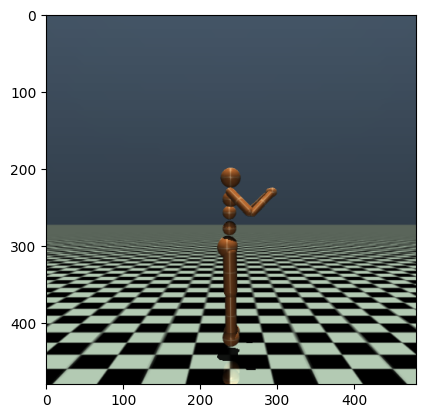

In [50]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import matplotlib.pyplot as plt

humanoid_env = gym.make("Humanoid-v5", render_mode="rgb_array")
print(f"action_space: {humanoid_env.action_space}")
print(f"state_space: {humanoid_env.observation_space}")
humanoid_env.reset()
plt.imshow(humanoid_env.render());